# Práctica 1. Exploración de Niveles del Lenguaje.

Por:   **Hanabi Hernández Arce**

No. de Cuenta:   **322004416**

# Fonética

1. Con base en el sistema de búsqueda visto en la práctica 1, dónde se recibe una palabra ortográfica y devuelve sus transcripciones fonológicas, proponga una solución para los casos en que la palabra buscada no se encuentra en el lexicón/diccionario.

- ¿Cómo devolver o aproximar su transcripción fonológica?

- Reutiliza el sistema de búsqueda visto en clase y mejóralo con esta funcionalidad.

- Muestra al menos tres ejemplos


##  1.1 ¿Cómo devolver o aproximar su transcripción fonológica?

Creo que para el caso en el que la palabra no pertenezca al diccionario podemos aproximar su transcripción fonológica separando la palabra en cada símbolo de su alfabeto y después obtener la transcripción de cada símbolo. Finalmente unimos cada transcripción de los símbolos del alfabeto.

Ejemplo:

Palabra -> P / a / l / a / b / r / a -> pˈe / ˈa / ˈɛle / ˈa / ᵦˈe / ˈɛɾe / ˈa -> pˈeˈaˈɛleˈaᵦˈeˈɛɾeˈa


Esta solución tiene como ventaja: 
-  Devolver la transcripción al alfabeto fonológico de cualquier palabra en su lenguaje original.


Pero tiene como desventajas:
- Casi en ningún caso la transcripción será precisa.
- Debes tener la transcripción de cada símbolo perteneciente al alfabeto del lenguaje original al alfabeto fonológico.
- La palabra obtenida en la transcripción es el deletreo de la palabra original en una sola palabra.

En base a esta solución, considero que para hacercarnos más a la transcripción fonológica real, en algunos casos es conveniente separar las palabras por sílabas en lugar de símbolos unitarios del alfabeto.

Pero esta propuesta tiene como desventajas:
- Necesitas una algoritmo adicional para separar la palabra en sílabas.
- Ya no basta con tener la transcripción de cada símbolo del alfabeto, ahora necesitas la transcripción de todas las sílabas posibles en el lenguaje original al alfabeto fonológico.


Ejemplo:

Palabra -> Pa / la / bra -> pˈa / lˈa / bɾˈa -> pˈalˈabɾˈa 

(Esta aproximación es mucho más cercana a la transcripción real: Palabra -> palˈaβɾa)

## 1.2 Reutiliza el sistema de búsqueda visto en clase y mejóralo con esta funcionalidad.

Primero obtenemos los dataset que usaremos.

In [5]:
import http
from collections import defaultdict

import pandas as pd
import requests as r

from rich import print as rprint
from rich.columns import Columns
from rich.panel import Panel
from rich.text import Text

In [26]:
IPA_URL = "https://raw.githubusercontent.com/open-dict-data/ipa-dict/master/data/{lang}.txt"
response = r.get(IPA_URL.format(lang="es_MX"))
ipa_list = response.text[:1000].split("\n")

In [36]:
def download_ipa_corpus(iso_lang: str) -> str:
    """Get ipa-dict file from Github

    Parameters:
    -----------
    iso_lang:
        Language as iso code

    Results:
    --------
    dict:
        Dictionary with words as keys and phonetic representation
        as values for a given lang code
    """
    print(f"Downloading {iso_lang}", end="::")
    response = r.get(IPA_URL.format(lang=iso_lang))
    status_code = response.status_code
    print(f"status={status_code}")
    if status_code != http.HTTPStatus.OK:
        print(f"ERROR on {iso_lang} :(")
        return ""
    return response.text

In [34]:
def parse_response(response: str) -> dict:
    """Parse text response from ipa-dict to python dict

    Each row have the format:
    [WORD][TAB]/[IPA]/(, /[IPA]/)?

    Parameters
    ----------
    response: str
        ipa-dict raw text

    Returns
    -------
    dict:
        A dictionary with the word as key and the phonetic
        representations as value
    """
    ipa_list = response.rstrip().split("\n")
    result = {}
    for item in ipa_list:
        if item == '':
            continue
        item_list = item.split("\t")
        result[item_list[0]] = item_list[1]
    return result

In [37]:
es_data = parse_response(download_ipa_corpus("es_MX"))

In [38]:
def get_ipa_transcriptions(word: str, dataset: dict) -> list[str]:
    """Search for a word in an IPA phonetics dict

    Given a word this function return the IPA transcriptions

    Parameters:
    -----------
    word: str
        A word to search in the dataset
    dataset: dict
        A dataset for a given language code

    Returns
    -------
    list[str]:
        List with posible transcriptions if any,
        else an empty list
    """
    return dataset.get(word.lower(), "").split(", ")

In [39]:
get_ipa_transcriptions("mayonessa", es_data)

['']

Como podemos observar, mayonessa no está en el dataset. 

Así que actualizaré la implementación de get_ipa_transcriptions para que transcriba palabras aunque no pertenezcan al dataset. 

Aplicaremos una mezcla entre la propuesta original y la propuesta de separar por sílabas.
Dicha mezcla consiste en separar la palabra letra por letra pero no asignar la transcripción como si fuera la letra sola, en su lugar asignaremos la transcripción como si la letra fuera parte de una sílaba.

Este cambio hará la implementación más precisa, parecida a la opción de separación por sílabas original. 

In [65]:
""" Diccionario de cada letra a IPA (vocales con tílde y con diéresis)"""
ipa_letters = {
    "a": "a",
    "á": "a",
    "b": "b",
    "c": "k",
    "d": "d",
    "e": "e",
    "é": "e",
    "f": "f",
    "g": "g",
    "h": "",
    "i": "i",
    "í": "i",
    "j": "x",
    "k": "k",
    "l": "l",
    "m": "m",
    "n": "n",
    "ñ": "ɲ",
    "o": "o",
    "ó": "o",
    "p": "p",
    "q": "k",
    "r": "ɾ",
    "s": "s",
    "t": "t",
    "u": "u",
    "ú": "u",
    "ü": "u",
    "v": "b",
    "w": "w",
    "x": "ks",
    "y": "ʝ",
    "z": "s"
}

In [46]:
""" Función que hace la transcripción usando nuestro diccionario """
def word_to_letters_to_ipa(word: str, ipa_map: dict) -> str:
    ipa_result = ""

    for letter in word.lower():
        ipa_result += ipa_map.get(letter, "")

    return ipa_result

In [51]:
""" Función original que además usa nuestra implementación """
def get_ipa_transcriptions_or_create_one(word: str, dataset: dict) -> list[str]:
    """Search for a word in an IPA phonetics dict"""

    result = dataset.get(word.lower())

    if result:
        return result.split(", ")
    
    return [word_to_letters_to_ipa(word, ipa_letters)]

In [52]:
get_ipa_transcriptions_or_create_one("mayonessa", es_data)

['maʝonessa']

Sin embargo, esta implementación tiene problema con las excepciones "rr", "ch" y "ll" 

In [53]:
get_ipa_transcriptions_or_create_one("Chillona", es_data)

['killona']

También con las sílabas "gue" y "gui".

In [66]:
get_ipa_transcriptions_or_create_one("Guelatao", es_data)

['guelatao']

## 1.3 Muestra al menos tres ejemplos

Aunque ya mostre algunos casos donde puede fallar, ahora mostrare los casos donde brilla.

Como referencia usaremos es_data para comparar los resultados.

In [72]:
get_ipa_transcriptions_or_create_one("Casos", {})

['kasos']

In [69]:
get_ipa_transcriptions_or_create_one("Casos", es_data)

['/kasos/']

In [73]:
get_ipa_transcriptions_or_create_one("Donde", {})

['donde']

get_ipa_transcriptions_or_create_one("Donde", es_data)

In [76]:
get_ipa_transcriptions_or_create_one("Ahora", {})

['aoɾa']

In [75]:
get_ipa_transcriptions_or_create_one("Ahora", es_data)

['/aoɾa/']

# Morfología

2. Elige tres lenguas del corpus que pertenezcan a familias lingüísticas distintas (spa-Romance, eng-Germánica, hun-Urálica) y para cada una de las tres lenguas calcula y compara:
- Ratio morfemas / palabra: El promedio de morfemas que componen las palabras
- Indicé de Flexión / Derivación: Del total de morfemas, ¿Qué porcentaje son etiquetas de flexión (100) y cuáles de derivación (010)?
  
3. Visualización

Genera una figura con subplots para comparar las lenguas lado a lado.
- Plot 1: Distribución de la longitud de los morfemas
- Plot 2: Distribución de las categorías (flexión, derivación, raíz, etc.)
  
4. Con base en esta información, responde la pregunta:
- ¿Cuál de las tres lenguas se comporta más como una lengua aglutinante y cuál como una lengua aislante?
- Justifica tu respuesta usando tus métricas y figuras


## 2.1 Ratio morfemas / palabra: El promedio de morfemas que componen una palabara

Utilizaremos las siguientes lenguas: ***Español-Romance, Mongol-Mongólica e Inglés-Germánica.***

In [81]:
response_spa = r.get("https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/main/data/spa.word.test.gold.tsv")

In [82]:
response_mon = r.get("https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/main/data/mon.word.test.gold.tsv")

In [83]:
response_eng = r.get("https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/main/data/eng.word.test.gold.tsv")

In [84]:
word_list_spa = response_spa.text[:1000].split("\n")
word_list_mon = response_mon.text[:1000].split("\n")
word_list_eng = response_eng.text[:1000].split("\n")

In [88]:
LANGS = {
    "ces": "Czech",
    "eng": "English",
    "fra": "French",
    "hun": "Hungarian",
    "spa": "Spanish",
    "ita": "Italian",
    "lat": "Latin",
    "rus": "Russian",
    "mon": "Mongolian" # Agrego el mongol que no estaba 
}
CATEGORIES = {
    "100": "Inflection",
    "010": "Derivation",
    "101": "Inflection, Compound",
    "000": "Root",
    "011": "Derivation, Compound",
    "110": "Inflection, Derivation",
    "001": "Compound",
    "111": "Inflection, Derivation, Compound"
}


In [89]:
def get_track_files(lang: str, track: str = "word") -> list[str]:
    """Genera una lista de nombres de archivo del shared task

    Con base en el idioma y el track obtiene el nombre de los archivos
    para con información reelevante para hacer análisis estadístico.
    Esto es archivos .test y .dev

    Parameters:
    ----------
    lang : str
        Idioma para el cual se generarán los nombres de archivo.
    track : str, optional
        Track del shared task de donde vienen los datos (por defecto es "word").

    Returns:
    -------
    list[str]
        Una lista de nombres de archivo generados para el idioma y la pista especificados.
    """
    return [
        f"{lang}.{track}.test.gold",
        f"{lang}.{track}.dev",
    ]

In [90]:
get_track_files("mon")

['mon.word.test.gold', 'mon.word.dev']

In [91]:
def get_raw_corpus(files: list) -> list:
    """Descarga y concatena los datos de los archivos tsv desde una URL base.

    Parameters:
    ----------
    files : list
        Lista de nombres de archivos (sin extensión) que se descargarán
        y concatenarán.

    Returns:
    -------
    list
        Una lista que contiene los contenidos descargados y concatenados
        de los archivos tsv.
    """
    result = []
    for file in files:
        print(f"Downloading {file}.tsv", end=" ")
        response = r.get(f"https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/main/data/{file}.tsv")
        print(f"status={response.status_code}")
        lines = response.text.split("\n")
        result.extend(lines[:-1])
    return result

In [92]:
def raw_corpus_to_dataframe(corpus_list: list, lang: str) -> pd.DataFrame:
    """Convierte una lista de datos de corpus en un DataFrame

    Parameters:
    ----------
    corpus_list : list
        Lista de líneas del corpus a convertir en DataFrame.
    lang : str
        Idioma al que pertenecen los datos del corpus.

    Returns:
    -------
    pd.DataFrame
        Un DataFrame de pandas que contiene los datos del corpus procesados.
    """
    data_list = []
    for line in corpus_list:
        try:
            word, tagged_data, category = line.split("\t")
        except ValueError:
            # Caso donde no existe la categoria
            word, tagged_data = line.split("\t")
            category = "NOT_FOUND"
        morphemes: list = tagged_data.split()
        data_list.append(
            {"words": word, "morph": morphemes, "category": category, "lang": lang}
        )
    df = pd.DataFrame(data_list)
    df["word_len"] = df["words"].apply(lambda word: len(word))
    df["morph_count"] = df["morph"].apply(lambda list: len(list))
    return df

In [95]:
files_spa = get_track_files("spa")
raw_spa = get_raw_corpus(files_spa)
df_spa = raw_corpus_to_dataframe(raw_spa, lang="spa")

files_mon = get_track_files("mon")
raw_mon= get_raw_corpus(files_mon)
df_mon = raw_corpus_to_dataframe(raw_mon, lang="mon")

files_eng = get_track_files("eng")
raw_eng = get_raw_corpus(files_eng)
df_eng = raw_corpus_to_dataframe(raw_eng, lang="eng")


In [96]:
df_mon.head(5)

,words,morph,category,lang,word_len,morph_count
0,гуяаар,"[гуя, @@аар]",100,mon,6,2
1,цэвэрлэгээг,"[цэвэр, @@лэх, @@гээ, @@г]",110,mon,11,4
2,дурны,"[дур, @@ы]",100,mon,5,2
3,үйлчлэгчид,"[үйл, @@члэх, @@гч, @@д]",110,mon,10,4
4,шувуунд,"[шувуу, @@д]",100,mon,7,2


In [104]:
# (Tenemos listos nuestros data frames con la información morfológica que usaremos :D)

Finalmente, simplemente calculamos el promedio de la columna de morfemas en cada lengua.

In [108]:
promedio_spa = df_spa['morph_count'].mean()
print(f"Promedio de morfemas por palabra (Español-Romance): {promedio_spa:.5f}")

promedio_mon = df_mon['morph_count'].mean()
print(f"Promedio de morfemas por palabra (Mongol-Mongólica): {promedio_mon:.5f}")

promedio_eng = df_eng['morph_count'].mean()
print(f"Promedio de morfemas por palabra (Inglés-Germánica): {promedio_eng:.5f}")

Promedio de morfemas por palabra (Español-Romance): 3.23623
Promedio de morfemas por palabra (Mongol-Mongólica): 2.56842
Promedio de morfemas por palabra (Inglés-Germánica): 2.35323


## Indicé de Flexión / Derivación: Del total de morfemas, ¿Qué porcentaje son etiquetas de flexión (100) y cuáles de derivación (010)?

In [119]:
total_words_spa = len(df_spa)
count_category_spa = df_spa['category'].value_counts()

spa_100 = count_category_spa.get('100', 0) 
spa_010 = count_category_spa.get('010', 0) 

ratio = spa_100 / spa_010
print(f"Palabras con categoría 100 (flexión): {spa_100}")
print(f"Palabras con categoría 010 (derivación): {spa_010}")
print(f"Ratio flexión/derivación: {ratio:.3f}")

Palabras con categoría 100 (flexión): 84377
Palabras con categoría 010 (derivación): 5710
Ratio flexión/derivación: 14.777


In [118]:
total_words_mon = len(df_mon)
count_category_mon = df_mon['category'].value_counts()

mon_100 = count_category_mon.get('100', 0) 
mon_010 = count_category_mon.get('010', 0) 

ratio = mon_100 / mon_010

print(f"Palabras con categoría 100 (flexión): {mon_100}")
print(f"Palabras con categoría 010 (derivación): {mon_010}")
print(f"Ratio flexión/derivación: {ratio:.3f}")

Palabras con categoría 100 (flexión): 727
Palabras con categoría 010 (derivación): 221
Ratio flexión/derivación: 3.290


In [120]:
total_words_eng = len(df_eng)
count_category_eng = df_eng['category'].value_counts()

eng_100 = count_category_eng.get('100', 0) 
eng_010 = count_category_eng.get('010', 0) 

ratio = eng_100 / eng_010
print(f"Palabras con categoría 100 (flexión): {eng_100}")
print(f"Palabras con categoría 010 (derivación): {eng_010}")
print(f"Ratio flexión/derivación: {ratio:.3f}")

Palabras con categoría 100 (flexión): 24242
Palabras con categoría 010 (derivación): 42105
Ratio flexión/derivación: 0.576


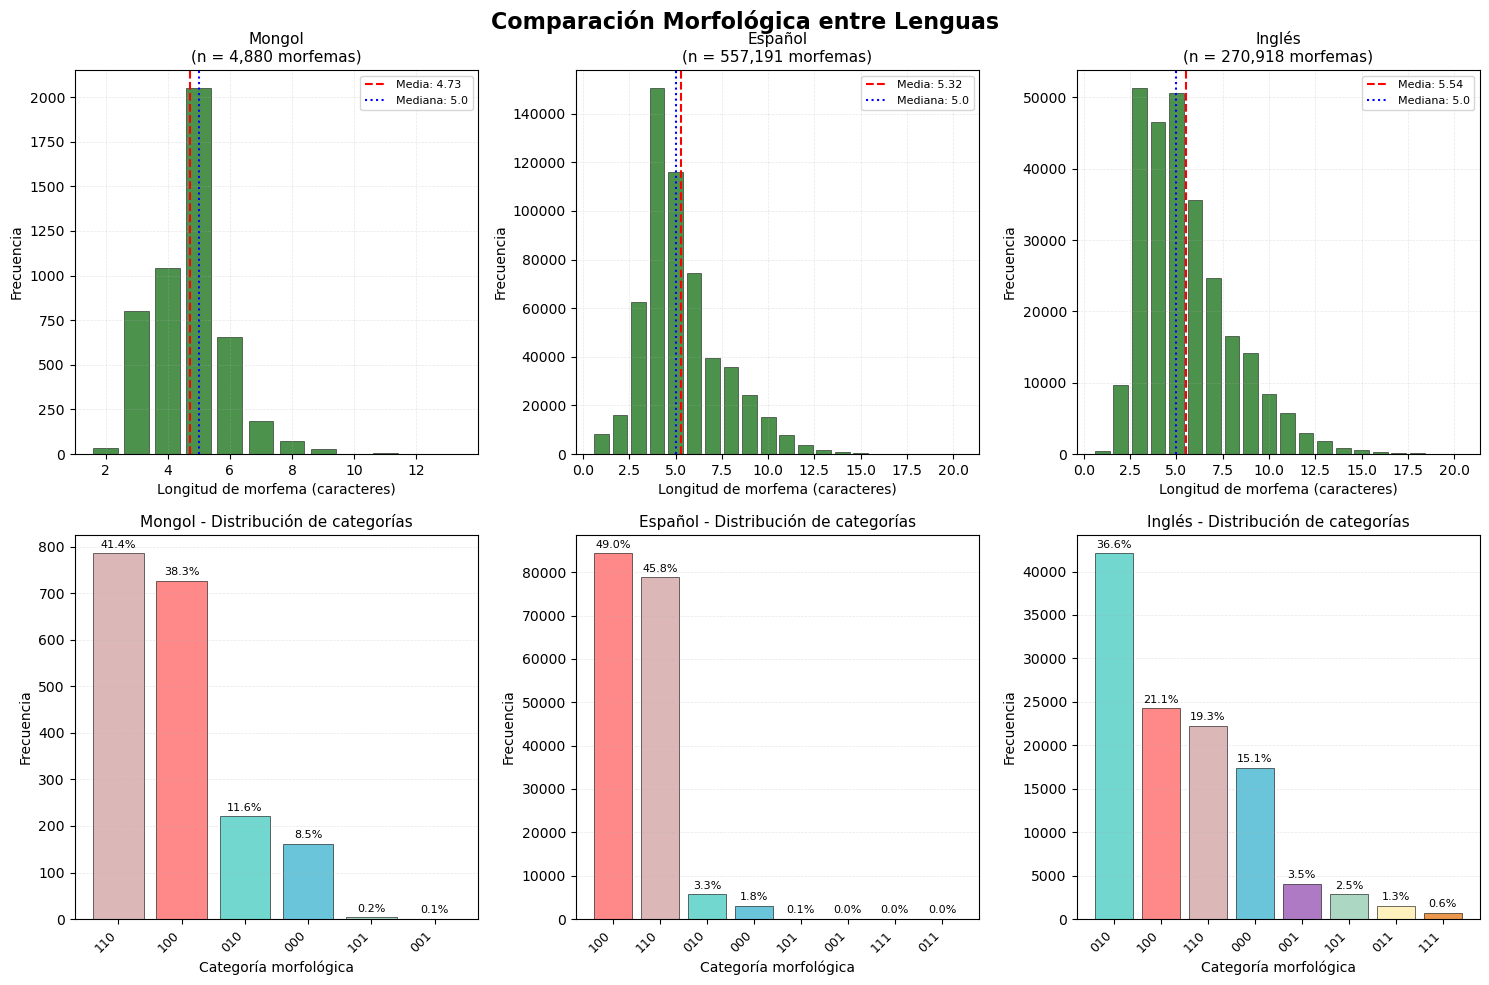

In [124]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Configuración general
plt.style.use('default')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Comparación Morfológica entre Lenguas', fontsize=16, fontweight='bold')

# Datos
dataframes = {
    'Mongol': df_mon,
    'Español': df_spa,
    'Inglés': df_eng
}

# Colores para categorías (mismo esquema)
category_colors = {
    '100': '#FF6B6B',  # Inflection - rojo
    '010': '#4ECDC4',  # Derivation - turquesa
    '000': '#45B7D1',  # Root - azul
    '101': '#96CEB4',  # Inflection, Compound - verde
    '011': '#FFEEAD',  # Derivation, Compound - amarillo
    '110': '#D4A5A5',  # Inflection, Derivation - rosado
    '001': '#9B59B6',  # Compound - púrpura
    '111': '#E67E22'   # Inflection, Derivation, Compound - naranja
}

# PLOT 1: Distribución de longitud de MORFEMAS (no de palabras)
for i, (lang, df) in enumerate(dataframes.items()):
    ax = axes[0, i]
    
    # Extraer TODOS los morfemas individuales de todas las palabras
    todos_morfemas = []
    for lista_morf in df['morph']:
        # Si la lista contiene strings (morfemas)
        if isinstance(lista_morf, list):
            todos_morfemas.extend(lista_morf)
    
    # Calcular longitud de cada morfema (caracteres)
    longitudes_morfemas = [len(m) for m in todos_morfemas]
    
    # Crear distribución de frecuencias
    freq_dist = Counter(longitudes_morfemas)
    longitudes = sorted(freq_dist.keys())
    frecuencias = [freq_dist[l] for l in longitudes]
    
    # Limitar a longitudes más comunes para mejor visualización (opcional)
    # Mostrar solo longitudes hasta 20 caracteres (ajusta según tus datos)
    mask = [l <= 20 for l in longitudes]
    longitudes_filt = [l for l, m in zip(longitudes, mask) if m]
    frecuencias_filt = [f for f, m in zip(frecuencias, mask) if m]
    
    # Crear gráfico de barras
    ax.bar(longitudes_filt, frecuencias_filt, color='darkgreen', alpha=0.7, 
           edgecolor='black', linewidth=0.5)
    
    # Personalizar
    ax.set_xlabel('Longitud de morfema (caracteres)', fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.set_title(f'{lang}\n(n = {len(todos_morfemas):,} morfemas)', fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Estadísticas
    media_long = np.mean(longitudes_morfemas)
    mediana_long = np.median(longitudes_morfemas)
    ax.axvline(media_long, color='red', linestyle='--', linewidth=1.5, 
               label=f'Media: {media_long:.2f}')
    ax.axvline(mediana_long, color='blue', linestyle=':', linewidth=1.5,
               label=f'Mediana: {mediana_long:.1f}')
    ax.legend(fontsize=8)

# PLOT 2: Distribución de categorías morfológicas (igual que antes)
for i, (lang, df) in enumerate(dataframes.items()):
    ax = axes[1, i]
    
    # Calcular porcentajes de categorías
    category_counts = df['category'].value_counts()
    total = len(df)
    percentages = (category_counts / total * 100).round(1)
    
    # Ordenar por frecuencia descendente
    categories = category_counts.index
    counts = category_counts.values
    colors = [category_colors.get(cat, '#95A5A6') for cat in categories]
    
    # Crear barras
    bars = ax.bar(range(len(categories)), counts, color=colors, alpha=0.8, 
                  edgecolor='black', linewidth=0.5)
    
    # Personalizar ejes
    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories, rotation=45, ha='right', fontsize=9)
    ax.set_xlabel('Categoría morfológica', fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.set_title(f'{lang} - Distribución de categorías', fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, axis='y')
    
    # Añadir porcentajes
    for bar, cat, pct in zip(bars, categories, percentages):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + (max(counts)*0.01),
                f'{pct}%', ha='center', va='bottom', fontsize=8)

# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

## Con base en esta información, responde la pregunta:
## - ¿Cuál de las tres lenguas se comporta más como una lengua aglutinante y cuál como una lengua aislante?
## - Justifica tu respuesta usando tus métricas y figuras

La más aglutinante es el ***Inglés-Germánico*** ya que la cantidad de palabras que pertenecen a la categoría 000 (raíz) y 001 (compuesta) es la más elevada entre las tres lenguas. Un dato en contra es que su ratio de morfemas por palabra es el más bajo entre los tres, aunque el español tampoco es aglutinante pero obtuvo el mayor ratio (≈3 morfemas por palabra). 

Notemos que, desde un inicio, comparar los resultados del español e inglés con el mongol no fue muy adecuado. El corpus del mongol está muy reducido en comparación a los otros y, probablemente, nos iba a dar resultados sesgados.

Dejando atras ese detalle, la lengua más aislante entre las tres es el ***Español-Romance*** ya que, aunque tiene el ratio mayor de morfemas por palabra, sigue siendo totalmente dominada en las categorías morfológicas por la flexión (el 49% de las palabras) y por flexion-derivación (otro 45% de las palabras). Creo que está claro que la naturaleza flexiva del latín se mantiene hasta hoy en el español)

Honestamente, los datos obtenidos no concuerdan con la realidad. La lengua más aglutinante debió ser el Mongol. 

Nuestros datos indican que el mongol esta entre una flexiva y una aislante, aunque normalmente se menciona que el mongol es aglutinante y el inglés más aislante.

¿Por qué no concluí que el mongol fuera la más aglutinante?

Segun nuestros plots y metricas, el español comparado con el mongol tiene aproximadamente un morfema más por palabra con: 3.2 morfemas/palabra (spa) > 2.5 morfemas/palabra (mon). Además, el inglés tiene una mayor cantidad de palabras 001 (compuestas) con un 3.5% de sus palabras, en tanto que sólo el 0.1% de las palabras del mongol pertenecen a la categoría compuesta. 

# Nivel de uso de LLM en esta práctica


Para la parte de fonética: Nivel 2. Estructura e ideas.

Principalmente por mi poca experiencia con python.

Y para la parte de morfología: Nivel 3. Co-autoría con agradecimientos en la tesis a shatcito

La verdad lo usé mucho más para la parte de los plots, en todo lo demás fue un Nivel 2 o Nivel 0.